In [45]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)
inputs.shape

torch.Size([6, 3])

In [46]:
x_2 = inputs[1]
d_in = inputs.shape[1]
print("Input Vector for 'journey':", x_2)
print("Input Dimension (d_in):", d_in)
d_out = 2

Input Vector for 'journey': tensor([0.5500, 0.8700, 0.6600])
Input Dimension (d_in): 3


In [47]:
# initialize the weights matrices Wq, Wk, Wv

torch.manual_seed(123)  # For reproducibility

W_query = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)

print("Weight Matrix W_query:\n", W_query)
print("Weight Matrix W_key:\n", W_key)
print("Weight Matrix W_value:\n", W_value)

Weight Matrix W_query:
 Parameter containing:
tensor([[-0.1115,  0.1204],
        [-0.3696, -0.2404],
        [-1.1969,  0.2093]])
Weight Matrix W_key:
 Parameter containing:
tensor([[-0.9724, -0.7550],
        [ 0.3239, -0.1085],
        [ 0.2103, -0.3908]])
Weight Matrix W_value:
 Parameter containing:
tensor([[ 0.2350,  0.6653],
        [ 0.3528,  0.9728],
        [-0.0386, -0.8861]])


In [48]:
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print("Query Vector for 'journey':", query_2)
print("Key Vector for 'journey':", key_2)
print("Value Vector for 'journey':", value_2)

Query Vector for 'journey': tensor([-1.1729, -0.0048])
Key Vector for 'journey': tensor([-0.1142, -0.7676])
Value Vector for 'journey': tensor([0.4107, 0.6274])


In [49]:
keys = inputs @ W_key
values = inputs @ W_value

print("Keys for All Input Elements:\n", keys)
print("Values for All Input Elements:\n", values)

Keys for All Input Elements:
 tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]])
Values for All Input Elements:
 tensor([[ 0.1196, -0.3566],
        [ 0.4107,  0.6274],
        [ 0.4091,  0.6390],
        [ 0.2436,  0.4182],
        [ 0.2653,  0.6668],
        [ 0.2728,  0.3242]])


In [50]:
# Attention Score

keys_2 = keys[1]
attention_score_2 = query_2 @ keys.T

print("Attention Score for Query 2:\n", attention_score_2)

d_k = keys.shape[-1]
print("Dimension of Key Vectors (d_k):", d_k)
atten_weights_2 = torch.softmax(attention_score_2 / d_k**0.5, dim=-1)
print("Attention Weights for Query 2:\n", atten_weights_2)

Attention Score for Query 2:
 tensor([ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809])
Dimension of Key Vectors (d_k): 2
Attention Weights for Query 2:
 tensor([0.1704, 0.1611, 0.1652, 0.1412, 0.2505, 0.1117])


In [51]:
context_vector_2 = atten_weights_2 @ values
print("Context Vector for 'journey':", context_vector_2)

Context Vector for 'journey': tensor([0.2854, 0.4081])


In [52]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        # Weights for query, key, and value transformations came from the trained model, so we set requires_grad=False to prevent them from being updated during training
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, inputs):
        keys = self.W_key(inputs)
        queries = self.W_query(inputs)
        values = self.W_value(inputs)

        attn_scores = queries @ keys.T
        print("key shapes", keys.shape)
        attn_weights = torch.softmax(attn_scores / torch.sqrt(torch.tensor(keys.shape[-1], dtype=torch.float32)), dim=-1)
        context_vectors = attn_weights @ values
        return context_vectors



In [53]:
d_in = inputs.shape[1]
d_out = 2
torch.manual_seed(123)  # For reproducibility
sa_v2 = SelfAttention_v2(d_in=d_in, d_out=d_out)
print(sa_v2(inputs))

key shapes torch.Size([6, 2])
tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


In [68]:
# Mask our attention weight on diagonal an normalize
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)

attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / torch.sqrt(torch.tensor(keys.shape[-1], dtype=torch.float32)), dim=-1)
print("Attention Weights Before Masking:\n", attn_weights)

context_lenght = attn_scores.shape[0]

mask_simple = torch.tril(torch.ones(context_lenght, context_lenght))
print("Mask:\n", mask_simple)

masked_simple_attn_weights = attn_weights * mask_simple
print("Masked Attention Weights Before Normalization:\n", masked_simple_attn_weights)

# Normalize the masked attention weights
row_sums = masked_simple_attn_weights.sum(dim=-1, keepdim=True)
normalized_masked_simple_attn_weights = masked_simple_attn_weights / row_sums
print("Normalized Masked Attention Weights:\n", normalized_masked_simple_attn_weights)

Attention Weights Before Masking:
 tensor([[0.1717, 0.1762, 0.1761, 0.1555, 0.1627, 0.1579],
        [0.1636, 0.1749, 0.1746, 0.1612, 0.1605, 0.1652],
        [0.1637, 0.1749, 0.1746, 0.1611, 0.1606, 0.1651],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.1632, 0.1674],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.1639],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)
Mask:
 tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])
Masked Attention Weights Before Normalization:
 tensor([[0.1717, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1749, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1637, 0.1749, 0.1746, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.0000, 0.0000],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.0000],
        [0.1624, 0.1709, 0.1706

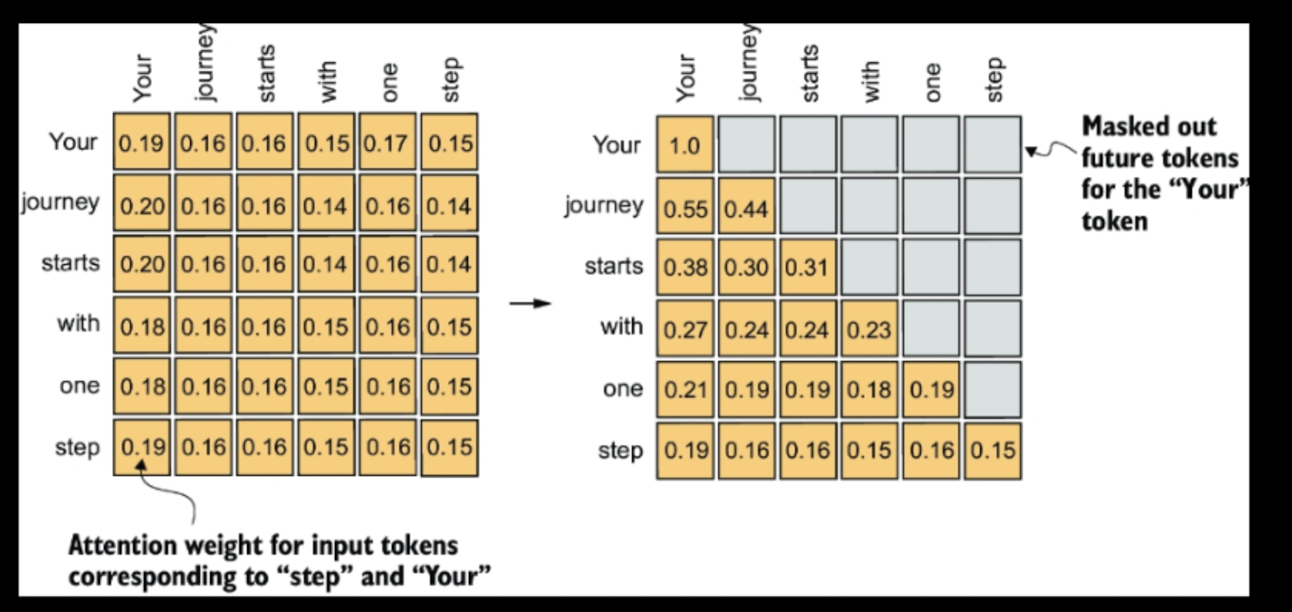

In [ ]:


values = sa_v2.W_value(inputs)

# Other option 

mask = torch.triu(torch.ones(context_lenght, context_lenght),diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print("Masked Attention Scores:\n", masked)

attn_weights_masked = torch.softmax(masked / torch.sqrt(torch.tensor(keys.shape[-1], dtype=torch.float32)), dim=-1)
print("Attention Weights After Masking:\n", attn_weights_masked)


Masked Attention Scores:
 tensor([[0.3111,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1655, 0.2602,   -inf,   -inf,   -inf,   -inf],
        [0.1667, 0.2602, 0.2577,   -inf,   -inf,   -inf],
        [0.0510, 0.1080, 0.1064, 0.0643,   -inf,   -inf],
        [0.1415, 0.1875, 0.1863, 0.0987, 0.1121,   -inf],
        [0.0476, 0.1192, 0.1171, 0.0731, 0.0477, 0.0966]],
       grad_fn=<MaskedFillBackward0>)
Attention Weights After Masking:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


## Dropout the attention weights

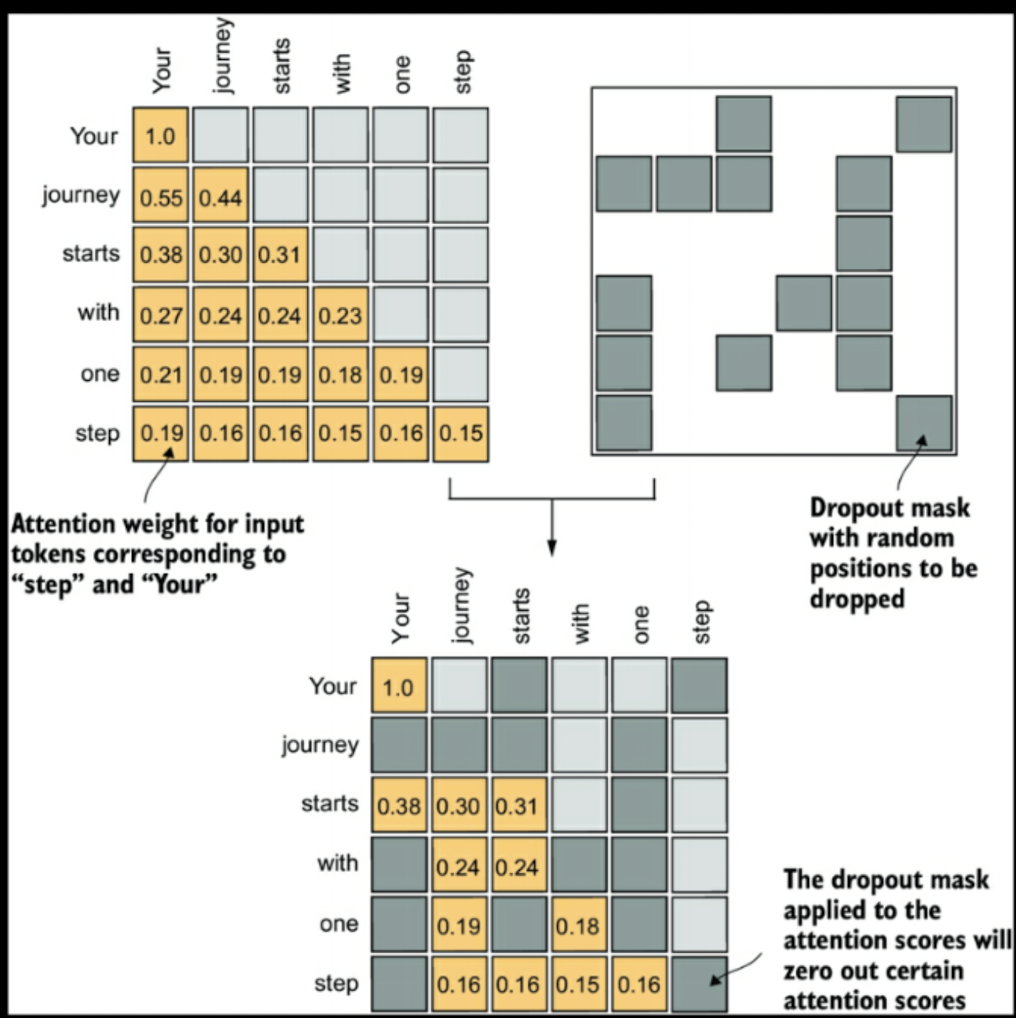

In [74]:
torch.manual_seed(123)  # For reproducibility
dropout = nn.Dropout(p=0.5)
example = torch.ones((6,6))
print("Example Tensor Before Dropout:\n", example)
dropped_example = dropout(example)
print("Example Tensor After Dropout:\n", dropped_example)


Example Tensor Before Dropout:
 tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
Example Tensor After Dropout:
 tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])
